# Natural-image feature examples

Frozen ResNet34 and a Top-16 SAE on a fixed CIFAR-10
sample. These are measured responses, not semantic
detector labels or recovered causal circuits.

In [1]:
from pathlib import Path
import sys
import json
root = Path.cwd()
while not (root / 'pyproject.toml').exists():
    if root == root.parent:
        raise RuntimeError('Open within the project')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
paper = root / 'texs/sparsesurrs/visionlattices'
folder = root / 'vision_tokens/cifar10_resnet34'

## Recompute feature selection and lattice extents

The standalone verification module also reproduces all
1,500 dense and sparse activation arrays from weights.
This notebook checks selection, scores, and queries.

In [2]:
from lattmc.vision.verify_natural_codexgen import (
    verify_natural)
print(json.dumps(verify_natural(inference=False), indent=2))
summary = json.loads(
    (folder / 'results/natural_codexgen.json').read_text())
print('Test reconstruction R2:',
      round(summary['test_reconstruction_r2'], 3))

{
  "images": 1500,
  "feature_galleries": 6,
  "lattice_queries": 8,
  "full_model_inference": false
}
Test reconstruction R2: 0.576


## Highest-activating examples and spatial maps

Each row uses the same color scale. Feature association
is selected from training labels; gallery examples are
ranked across all test classes. No mismatch is hidden.

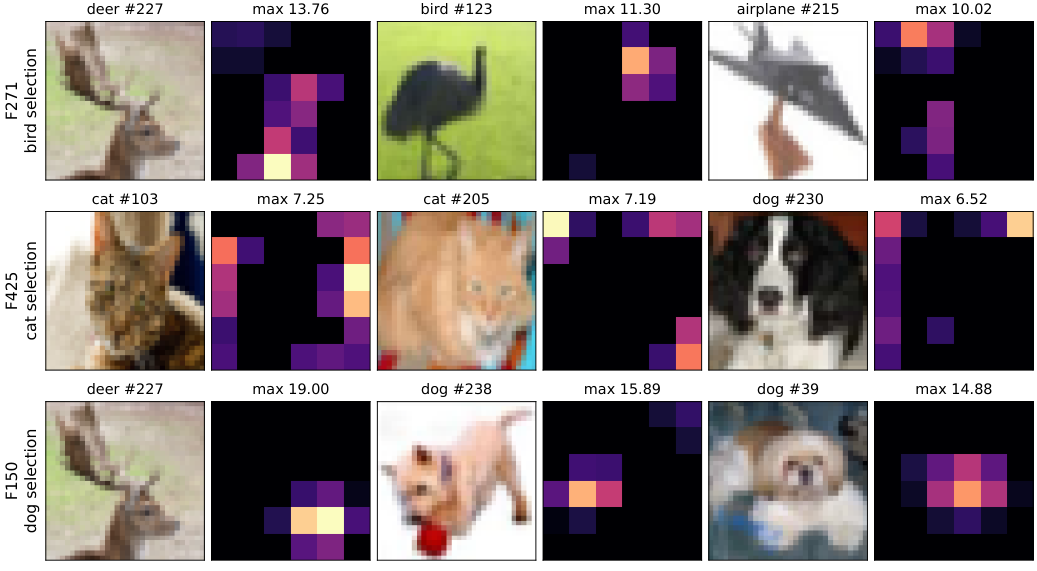

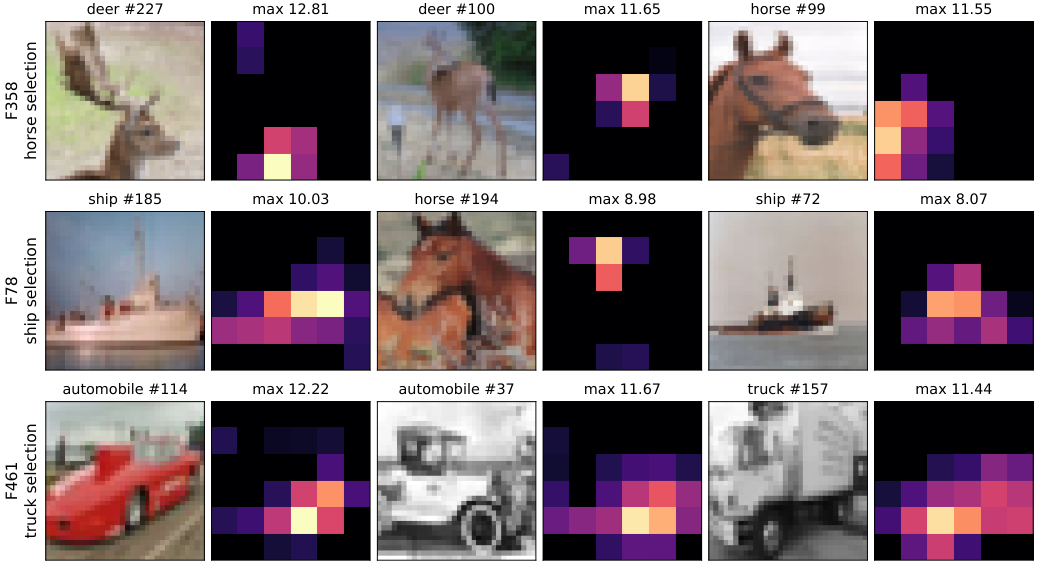

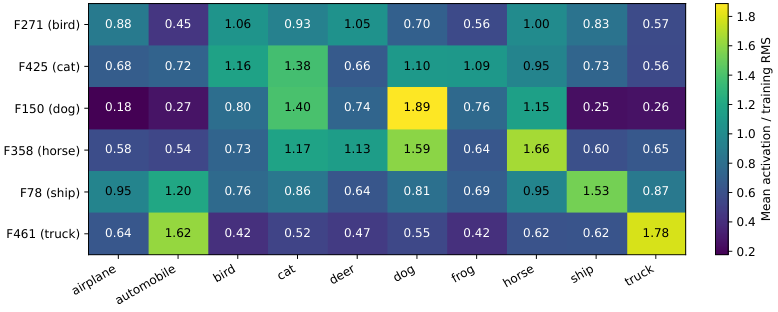

In [3]:
import pymupdf
from IPython.display import Image, display
def show_figure(name):
    with pymupdf.open(paper / 'figures' / name) as document:
        pix = document[0].get_pixmap(
            matrix=pymupdf.Matrix(1.2, 1.2), alpha=False)
        display(Image(data=pix.tobytes('png')))
show_figure('feature_animals_codexgen.pdf')
show_figure('feature_transport_codexgen.pdf')
show_figure('feature_tuning_codexgen.pdf')

## Meet and join examples

The query pairs are cat/dog and ship/truck. Extent counts
cover all test images; the pictures show at most three
ranked matches. A join conjoins numeric requirements,
not class labels. Same-site witnesses are separate.

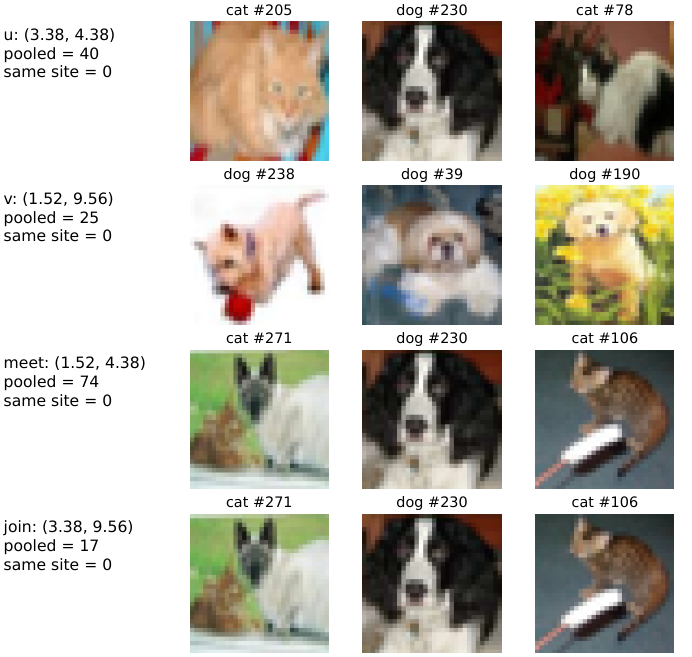

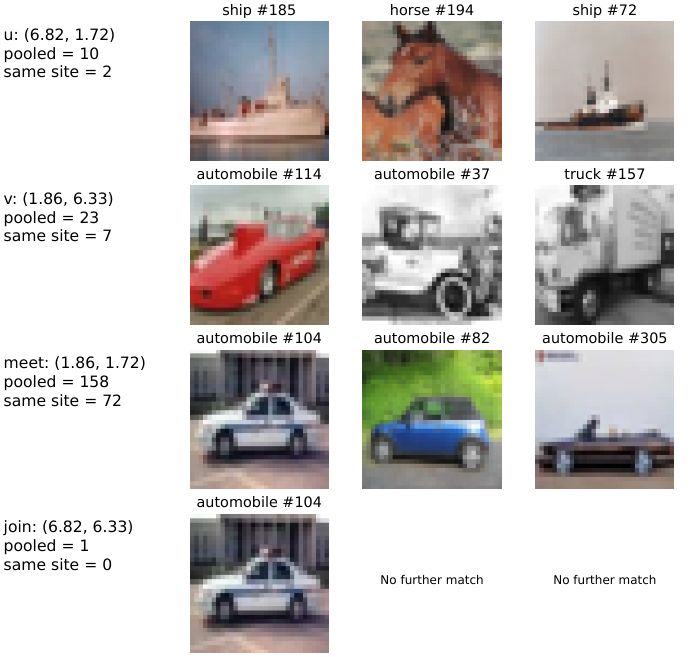

In [4]:
show_figure('query_cat_dog_codexgen.pdf')
show_figure('query_ship_truck_codexgen.pdf')

## Reproduce the figures

From the repository root:

```sh
PYTHONPATH=src uv run --no-sync python -m lattmc.vision.examples_codexgen
```

See vision_tokens/README.md for data provenance and
retraining commands. The mirrored repository is
https://github.com/levants/lattice-ml.